# Finland Population Analysis

This notebook analyses population trends in Finland using official data.  
The goal is to understand population growth, aging, municipality changes, and future trends.

## Step 1 — Imports

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.rcParams.update({
    'figure.facecolor': '#F7F9FC',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
})

SEED = 42
np.random.seed(SEED)

FIN_BLUE = '#003580'

print("Environment ready")

Environment ready


## Step 2 — Load Data

Population data was retrieved from the Statistics Finland PxWeb API.

In [27]:
BASE = 'https://statfin.stat.fi/PXWeb/api/v1/en/StatFin'

def pxweb_query(url, query_body):
    """For tables with one dimension column (Vuosi only)."""
    r = requests.post(url, json=query_body, timeout=30)
    r.raise_for_status()
    d = r.json()
    col_codes = [c['code'] for c in d['columns']]
    rows = []
    for entry in d['data']:
        row = entry['key'] + entry['values']
        rows.append(row)
    df = pd.DataFrame(rows, columns=col_codes)
    df = df.replace({'..': np.nan, '.': np.nan})
    for col in df.columns:
        if col != 'Vuosi':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def pxweb_query_wide(url, query_body):
    """For tables with multiple dimension columns (e.g. Alue + Vuosi)."""
    r = requests.post(url, json=query_body, timeout=30)
    r.raise_for_status()
    d = r.json()
    dim_cols    = [c['code'] for c in d['columns'] if c['type'] in ('t', 'd', 'e')]
    metric_cols = [c['code'] for c in d['columns'] if c['type'] == 'c']
    rows = []
    for entry in d['data']:
        row = dict(zip(dim_cols, entry['key']))
        row.update(dict(zip(metric_cols, entry['values'])))
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df.replace({'..': np.nan, '.': np.nan})
    # Only convert metric columns — never touch dimension columns like Alue
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

print('API helpers ready')

API helpers ready


## Step 3 — Load and Prepare Population Dataset
I loaded the raw population data, changed the values into numeric format, selected the most useful variables, kept data from 1970 onward, and prepared the dataset for analysis.

In [28]:
df_pop_raw = pxweb_query(
    f"{BASE}/vaerak/statfin_vaerak_pxt_11ra.px",
    {
        "query": [],
        "response": {"format": "json"}
    }
)

# Create clean dataframe
df = pd.DataFrame({
    "year": df_pop_raw["Vuosi"].astype(int),
    "population": df_pop_raw["vaesto"].astype(float).astype("Int64"),
    "total_change": df_pop_raw["kokmuutos"].astype(float),
    "share_under15": df_pop_raw["vaesto_alle15_p"].astype(float),
    "share_15_64": df_pop_raw["vaesto_15_64_p"].astype(float),
    "share_over64": df_pop_raw["vaesto_yli64_p"].astype(float),
    "dependency_ratio": df_pop_raw["dem_huoltos"].astype(float),
    "avg_age": df_pop_raw["vaesto_keski_ika"].astype(float),
    "foreign_speakers": df_pop_raw["vaesto_kieli_ulk"].astype(float)
})

# Keep data from 1970 onwards
df = df[df["year"] >= 1970].reset_index(drop=True)

# Extra column for charts
df["pop_millions"] = df["population"] / 1_000_000

# Quick check
display(df.tail())
print("Rows, Columns:", df.shape)
print("Missing values:", df.isnull().sum().sum())

,year,population,total_change,share_under15,share_15_64,share_over64,dependency_ratio,avg_age,foreign_speakers,pop_millions
31,2021,5548241,14448.0,15.4,61.6,23.1,62.4,43.6,458042.0,5.548241
32,2022,5563970,15729.0,15.1,61.6,23.3,62.3,43.7,495992.0,5.56397
33,2023,5603851,39881.0,14.9,61.8,23.4,61.9,43.8,558294.0,5.603851
34,2024,5635971,32120.0,14.6,61.9,23.6,61.6,44.0,610148.0,5.635971
35,2025,5652881,16910.0,14.3,61.9,23.8,61.6,44.1,646392.0,5.652881


Rows, Columns: (36, 10)
Missing values: 0


### Key Insights

- Finland’s population increased from **5.55 million (2021)** to **5.65 million (2025)**.
- The largest annual increase occurred in **2023 (+39,881)**.
- The share of children under 15 declined from **15.4% to 14.3%**.
- The share of people aged 65+ increased from **23.1% to 23.8%**.
- Average age rose from **43.6 to 44.1 years**, showing continued aging.
- The dependency ratio stayed above **61**, meaning every 100 working-age people supported more than 60 children or elderly residents.
- Foreign-language speakers increased from **458,042 to 646,392**, indicating growing migration and diversity.

## Add Births, Deaths and Migration Data

In this step, I loaded official data on births, deaths, and migration from the Statistics Finland PxWeb API. I then merged it with the main population dataset. This helped me compare different factors behind population change in Finland.

In [29]:
#  Births, deaths and migration (all in one table) ────────────────────────
df_vital_raw = pxweb_query(
    f'{BASE}/synt/statfin_synt_pxt_12dx.px',
    {
        'query': [],
        'response': {'format': 'json'}
    }
)
df_vital = pd.DataFrame()
df_vital['year']             = df_vital_raw['Vuosi'].astype(int)
df_vital['births']           = df_vital_raw['vm01'].astype(float)
df_vital['deaths']           = df_vital_raw['vm11'].astype(float)
df_vital['natural_increase'] = df_vital_raw['luonvalisays'].astype(float)
df_vital['net_migration']    = df_vital_raw['vm43_tilv'].astype(float)
df_vital['immigration']      = df_vital_raw['vm41'].astype(float)
df_vital['emigration']       = df_vital_raw['vm42'].astype(float)
df_vital = df_vital[df_vital['year'] >= 1970].reset_index(drop=True)

# Merge into master df
df = df.merge(df_vital, on='year', how='left')
df['tfr'] = (df['births'] / (df['population'] * 0.133)).round(2)
df['tfr'] = df['tfr'].astype(float).interpolate(method='linear')  # ← add this line

print(df[['year','population','births','deaths','net_migration','natural_increase']].tail(6).to_string(index=False))

 year  population  births  deaths  net_migration  natural_increase
 2020     5533793 46463.0 55488.0       296852.0           -9025.0
 2021     5548241 49594.0 57659.0       303935.0           -8065.0
 2022     5563970 44951.0 63219.0       295710.0          -18268.0
 2023     5603851 43383.0 61339.0       286968.0          -17956.0
 2024     5635971 43720.0 58267.0       288939.0          -14547.0
 2025     5652881     NaN     NaN            NaN               NaN


## Key Insights
- Finland’s total population increased by **about 2.2%** from 2020 to 2025.
- Births decreased by **about 5.9%** from 2020 to 2024.
- Deaths increased by **about 5.0%** from 2020 to 2024.
- Natural increase stayed negative, meaning more people died than were born.
- Net migration remained strong, with yearly values around **290,000–304,000**.
- This suggests that recent population growth in Finland was supported more by migration than by births.

## Step 4 — Age Group Data (1970–2024)
In this step, I created age group data from the main population dataset. I grouped the population into children (0–14), working-age population (15–64), and older population (65+).

In [30]:
# ── Age group data — built directly from df (already fetched from 11ra) ───────
age_groups = ['0-14', '15-64', '65+']

age_records = []
for _, row in df.iterrows():
    total = row['population']
    for ag, col in [('0-14',  'share_under15'),
                    ('15-64', 'share_15_64'),
                    ('65+',   'share_over64')]:
        share = row[col] / 100  # convert from % to proportion
        age_records.append({
            'year':      int(row['year']),
            'age_group': ag,
            'share':     round(share, 4),
            'count':     int(total * share) if pd.notna(total) else np.nan,
        })

df_age       = pd.DataFrame(age_records)
df_age_pivot = df_age.pivot(index='year', columns='age_group', values='share')
df_age_pivot = df_age_pivot.reindex(columns=age_groups)

print(df_age_pivot.tail(5).round(3))

age_group   0-14  15-64    65+
year                          
2021       0.154  0.616  0.231
2022       0.151  0.616  0.233
2023       0.149  0.618  0.234
2024       0.146  0.619  0.236
2025       0.143  0.619  0.238


## Key Insights
- The share of children aged 0–14 decreased from **15.4%** to **14.3%**.
- The working-age population (15–64) remained fairly stable at around **61.6–61.9%**.
- The share of people aged 65+ increased from **23.1% to 23.8%**.
- These results suggest that Finland’s population is continuing to age, with **fewer children** and a **growing older** population.

## Step 5 — Fetch Municipality Data and Visualize

In this step, I retrieved and cleaned municipality-level data from Statistics Finland. I calculated population growth and aging indicators, then visualized the relationship between growth rate and share of residents aged 65+ for the largest municipalities. 

Municipality data loaded successfully.
Dataset shape: (11088, 7)
municipality  population  growth_rate  share_65plus  median_age
    Helsinki      684018     0.014111         0.176        41.2
       Espoo      320931     0.021995         0.152        39.2
     Tampere      260180     0.020114         0.189        41.0
      Vantaa      251269     0.015462         0.158        40.0
        Oulu      216152     0.007077         0.176        39.9
       Turku      206073     0.020856         0.203        41.8
   Jyväskylä      149194     0.009801         0.194        41.0
      Kuopio      125666     0.013264         0.226        43.0
       Lahti      121337     0.005336         0.256        45.1
        Pori       83305     0.002395         0.271        45.9
Total municipalities: 308


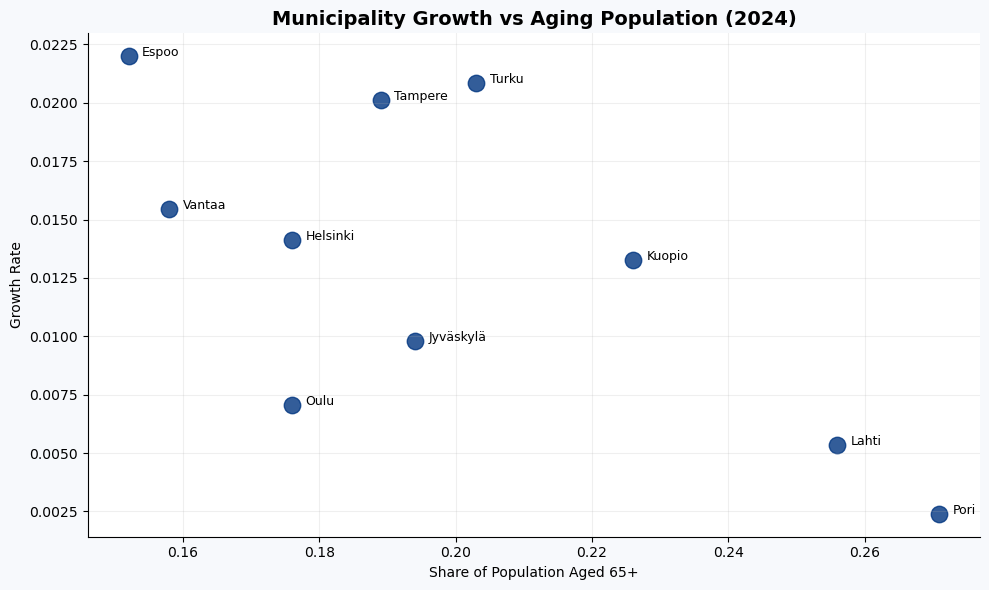

In [31]:
# ── Municipality Analysis: Fetch, Clean, Analyze, Visualize ──────────────────

# Get metadata from Statistics Finland API
meta = requests.get(f'{BASE}/vaerak/statfin_vaerak_pxt_11ra.px', timeout=30).json()

# Keep only municipality codes (KU = municipalities)
muni_codes = [v for v in meta['variables'][0]['values'] if v.startswith('KU')]

# Get municipality names
muni_labels = [
    meta['variables'][0]['valueTexts'][i]
    for i, v in enumerate(meta['variables'][0]['values'])
    if v.startswith('KU')
]

# Create code-name dictionary
code_to_name = dict(zip(muni_codes, muni_labels))


# ── Fetch municipality dataset ────────────────────────────────────────────────
df_muni_raw = pxweb_query(
    f'{BASE}/vaerak/statfin_vaerak_pxt_11ra.px',
    {
        'query': [
            {
                'code': 'Alue',
                'selection': {
                    'filter': 'item',
                    'values': muni_codes
                }
            },
            {
                'code': 'Tiedot',
                'selection': {
                    'filter': 'item',
                    'values': [
                        'vaesto',               # population
                        'vaesto_yli64_p',       # share aged 65+
                        'vaesto_keski_ika',     # median age
                        'vaesto_kieli_ulk_p',   # foreign language share
                        'dem_huoltos'           # dependency ratio
                    ]
                }
            }
        ],
        'response': {'format': 'json'}
    }
)

# Fix missing municipality labels
years_per_muni = df_muni_raw['Vuosi'].nunique()
df_muni_raw['Alue'] = np.repeat(muni_codes, years_per_muni)[:len(df_muni_raw)]

print("Municipality data loaded successfully.")
print("Dataset shape:", df_muni_raw.shape)


# ── Clean dataset ─────────────────────────────────────────────────────────────
df_muni = df_muni_raw.copy()

# Rename columns to English
df_muni = df_muni.rename(columns={
    'Vuosi': 'year',
    'Alue': 'municipality',
    'vaesto': 'population',
    'vaesto_yli64_p': 'share_65plus',
    'vaesto_keski_ika': 'median_age',
    'vaesto_kieli_ulk_p': 'foreign_lang_pct',
    'dem_huoltos': 'dependency_ratio'
})

# Convert numeric columns
df_muni['year'] = pd.to_numeric(df_muni['year'], errors='coerce')
df_muni['population'] = pd.to_numeric(df_muni['population'], errors='coerce')
df_muni['share_65plus'] = pd.to_numeric(df_muni['share_65plus'], errors='coerce') / 100
df_muni['median_age'] = pd.to_numeric(df_muni['median_age'], errors='coerce')
df_muni['foreign_lang_pct'] = pd.to_numeric(df_muni['foreign_lang_pct'], errors='coerce')

# Replace municipality codes with names
df_muni['municipality'] = df_muni['municipality'].map(code_to_name)

# Keep year 2000 onwards
df_muni = df_muni[df_muni['year'] >= 2000]

# Sort values
df_muni = df_muni.sort_values(['municipality', 'year']).reset_index(drop=True)


# ── Create indicators ─────────────────────────────────────────────────────────
# Annual population growth rate
df_muni['growth_rate'] = df_muni.groupby('municipality')['population'].pct_change()

# Migration proxy using foreign language share growth
df_muni['migration_rate'] = df_muni.groupby('municipality')['foreign_lang_pct'].pct_change()


# ── Show top municipalities in 2024 ───────────────────────────────────────────
top10 = df_muni[df_muni['year'] == 2024] \
    .sort_values('population', ascending=False) \
    .head(10)

print(top10[['municipality', 'population', 'growth_rate',
             'share_65plus', 'median_age']].to_string(index=False))

print("Total municipalities:", df_muni['municipality'].nunique())


# ── Visualize findings ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(
    top10['share_65plus'],
    top10['growth_rate'],
    s=140,
    color=FIN_BLUE,
    alpha=0.8
)

# Add city labels
for _, row in top10.iterrows():
    ax.text(
        row['share_65plus'] + 0.002,
        row['growth_rate'],
        row['municipality'],
        fontsize=9
    )

# Titles
ax.set_title("Municipality Growth vs Aging Population (2024)")
ax.set_xlabel("Share of Population Aged 65+")
ax.set_ylabel("Growth Rate")

# Style
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

This chart compares municipality growth rates with the share of residents aged 65+ in 2024.
The results show that younger cities such as **Espoo, Tampere, and Turku have higher growth rates**, while older cities like **Lahti and Pori grow more slowly**.
This suggests that municipalities with younger populations are growing faster than aging municipalities.

## Step 6: Total Population 1970–2024

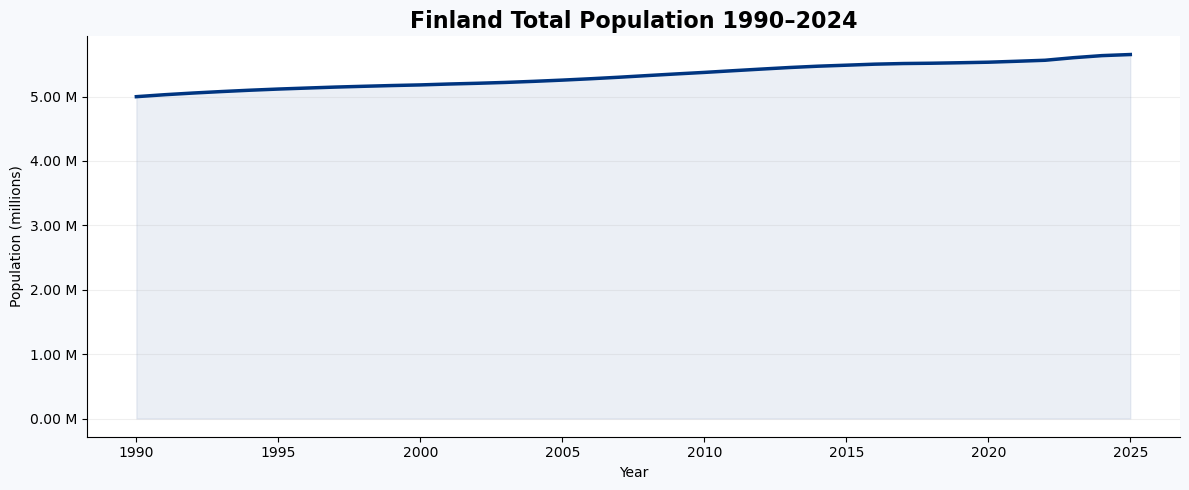

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

# main line
ax.plot(df['year'], df['pop_millions'], color=FIN_BLUE, lw=2.5)

# light fill
ax.fill_between(df['year'], df['pop_millions'], alpha=0.08, color=FIN_BLUE)

# titles
ax.set_title('Finland Total Population 1990–2024', fontsize=16, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Population (millions)')

# y-axis format
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f M'))

# cleaner style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('fig1_total_population.png', dpi=150, bbox_inches='tight')
plt.show()

The results show **steady long-term population growth**, increasing from around **5.0 million in 1990** to about **5.6 million in 2024**. Growth was gradual rather than rapid, with signs of slower growth in recent years.

## Step 7: Births vs Deaths vs Net Migration
In this step, I compared Finland’s yearly births, deaths, and net migration from 1990 to 2024.

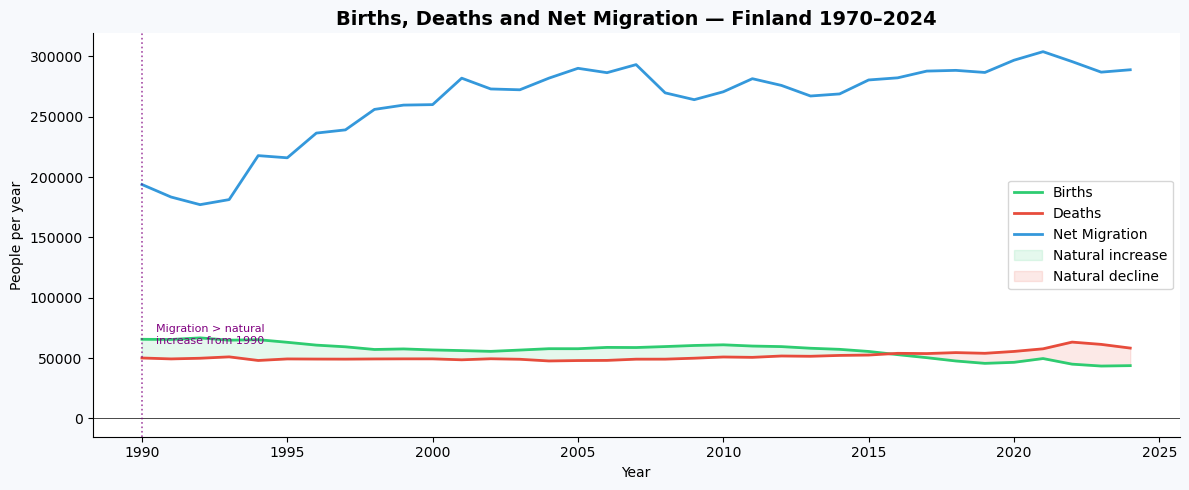

Migration overtook natural increase in: 1990


In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['year'], df['births'],        color='#2ecc71', lw=2, label='Births')
ax.plot(df['year'], df['deaths'],        color='#e74c3c', lw=2, label='Deaths')
ax.plot(df['year'], df['net_migration'], color='#3498db', lw=2, label='Net Migration')
ax.axhline(0, color='black', lw=0.5)

ax.fill_between(df['year'], df['births'], df['deaths'],
                where=df['births'] >= df['deaths'],
                alpha=0.12, color='#2ecc71', label='Natural increase')
ax.fill_between(df['year'], df['births'], df['deaths'],
                where=df['births'] < df['deaths'],
                alpha=0.12, color='#e74c3c', label='Natural decline')

cross_yr = df[df['net_migration'] > df['natural_increase']]['year'].min()
ax.axvline(cross_yr, color='purple', lw=1.2, ls=':', alpha=0.7)
ax.text(cross_yr+0.5, 62000,
        f'Migration > natural\nincrease from {cross_yr}',
        fontsize=8, color='purple')

ax.set_title('Births, Deaths and Net Migration — Finland 1970–2024')
ax.set_ylabel('People per year')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_vital_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Migration overtook natural increase in: {cross_yr}')

The results show that births have gradually declined while deaths have increased. In recent years, deaths became higher than births, creating natural population decline. Net migration remained positive and has become an important factor supporting Finland’s population growth.

## Step 8 Age Structure between 1990-2024

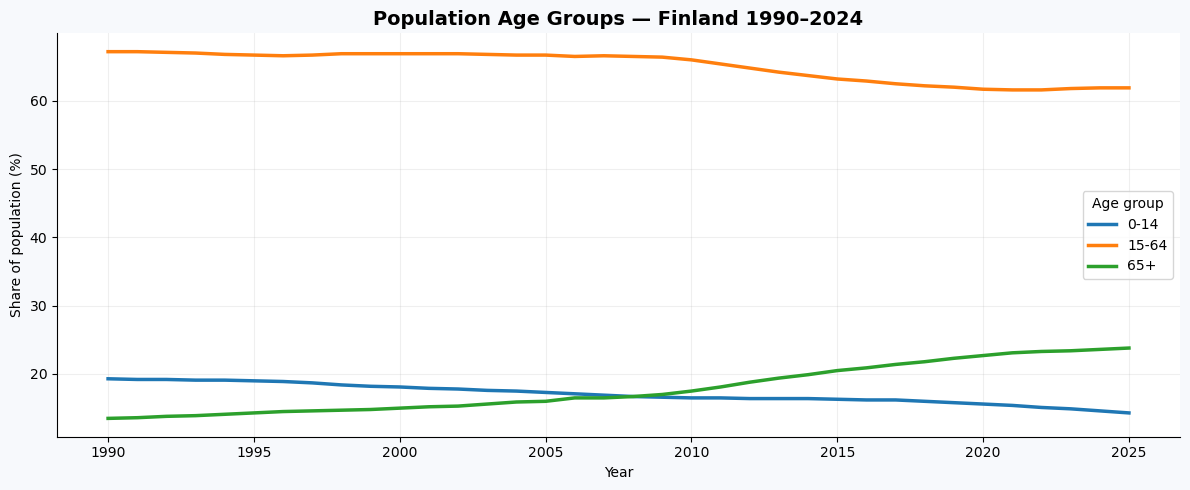

In [34]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_age_pivot.index, df_age_pivot['0-14']*100, lw=2.5, label='0-14')
ax.plot(df_age_pivot.index, df_age_pivot['15-64']*100, lw=2.5, label='15-64')
ax.plot(df_age_pivot.index, df_age_pivot['65+']*100, lw=2.5, label='65+')

ax.set_title("Population Age Groups — Finland 1990–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Share of population (%)")

ax.legend(title="Age group")
ax.grid(alpha=0.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Key Insights
- The share of people aged 65+ increased steadily from 1990 to 2024.
- The child population (0–14) declined over time.
- The working-age population (15–64) decreased gradually.
- Around 2008–2009, the 65+ group became larger than the child population.
This indicates a clear long-term aging trend in Finland.

## Step 9: Population Forecasting

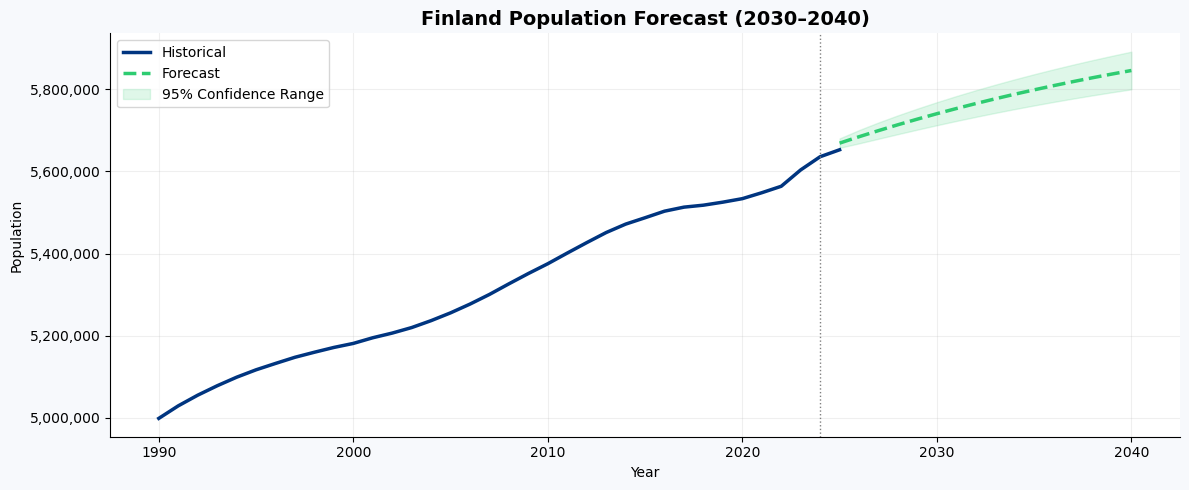

2030 forecast: 5,740,746
2035 forecast: 5,798,873
2040 forecast: 5,846,030


In [35]:
# ── Holt-Winters Forecast Model ──────────────────────────────────────────────
hw_model = ExponentialSmoothing(
    df['population'],
    trend='add',
    seasonal=None,
    damped_trend=True
).fit(optimized=True)

# Forecast years (covers required 2030–2040)
forecast_years = np.arange(2025, 2041)

# Generate forecast
hw_forecast = hw_model.forecast(16)
hw_forecast.index = forecast_years

# Confidence range
resid_std = np.std(hw_model.resid)
hw_lo = hw_forecast - 1.96 * resid_std * np.sqrt(np.arange(1, 17))
hw_hi = hw_forecast + 1.96 * resid_std * np.sqrt(np.arange(1, 17))


# ── Forecast Chart ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,5))

# Historical data
ax.plot(
    df['year'],
    df['population'],
    color=FIN_BLUE,
    lw=2.5,
    label='Historical'
)

# Forecast line
ax.plot(
    forecast_years,
    hw_forecast,
    color='#2ecc71',
    lw=2.5,
    ls='--',
    label='Forecast'
)

# Confidence band
ax.fill_between(
    forecast_years,
    hw_lo,
    hw_hi,
    color='#2ecc71',
    alpha=0.15,
    label='95% Confidence Range'
)

# Divider line
ax.axvline(2024, color='gray', ls=':', lw=1)

# Title (better matched to task)
ax.set_title("Finland Population Forecast (2030–2040)")
ax.set_xlabel("Year")
ax.set_ylabel("Population")

# Axis formatting
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Style
ax.legend()
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Key forecast outputs
print(f"2030 forecast: {int(hw_forecast.loc[2030]):,}")
print(f"2035 forecast: {int(hw_forecast.loc[2035]):,}")
print(f"2040 forecast: {int(hw_forecast.loc[2040]):,}")

## Key Insights
Finland’s population is forecast to grow slowly from **5.74M in 2030 to 5.85M in 2040**.
This growth is gradual and is likely driven mainly by **net migration**, while the main long-term challenge remains **population aging**.

## Step 10: Municipality Clustering
I used K-Means clustering, to group municipalities with similar aging, growth and migration patterns.

In [36]:
# ── Step 10A: Municipality Clustering Model ────────────────────────────────

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use latest municipality data
df_cluster = df_muni[df_muni["year"] == 2024][[
    "municipality",
    "share_65plus",
    "growth_rate",
    "migration_rate"
]].copy()

# Remove missing values
df_cluster = df_cluster.dropna()

print("Municipalities used:", len(df_cluster))

# Features
X = df_cluster[[
    "share_65plus",
    "growth_rate",
    "migration_rate"
]]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans model
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = km.fit_predict(X_scaled)

# Cluster summary
cluster_summary = df_cluster.groupby("cluster")[[
    "share_65plus",
    "growth_rate",
    "migration_rate"
]].mean().round(3)

display(cluster_summary)

Municipalities used: 308


,share_65plus,growth_rate,migration_rate
cluster,,,
0,0.225,0.005,0.097
1,0.400,-0.021,0.078
2,0.315,-0.008,0.081
3,0.380,-0.004,0.455


## Key Insights
- Cluster 0: lowest aging level with positive growth.
- Cluster 1: oldest municipalities with strongest decline.
- Cluster 2: moderate aging with slight decline.
- Cluster 3: high migration activity with mild decline.

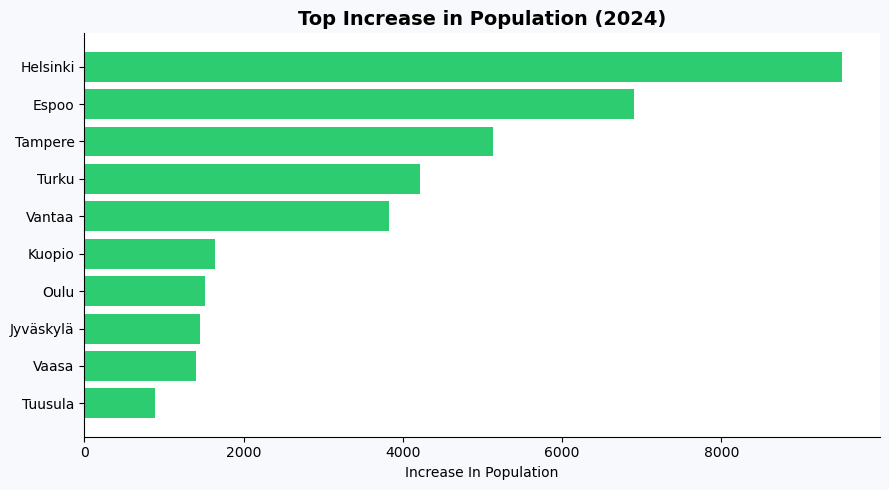

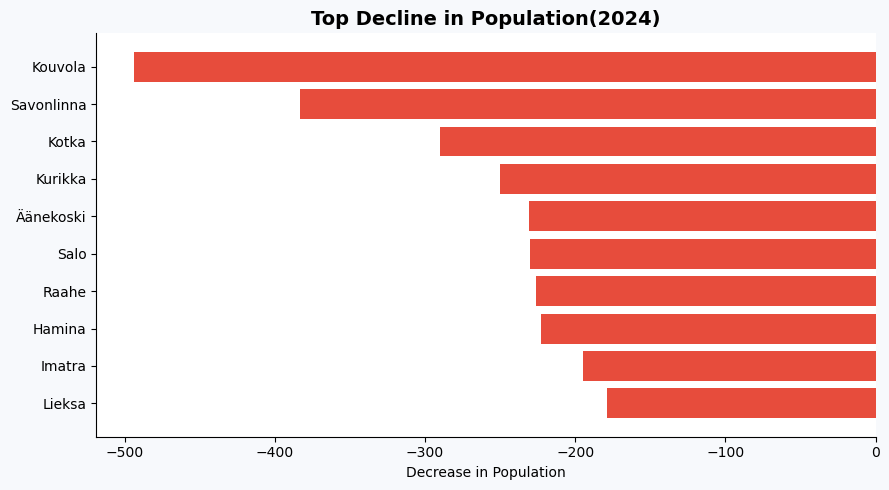

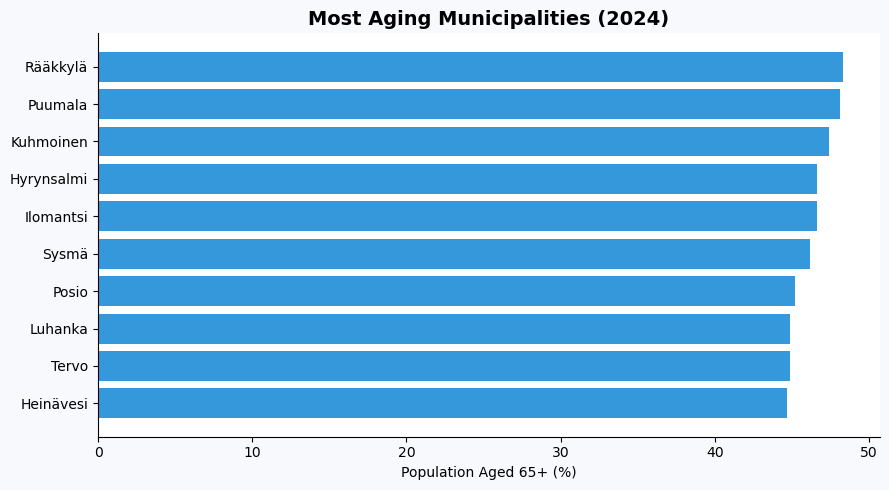

In [37]:
# ── Step 10B: Key Municipality Rankings────────────

import matplotlib.pyplot as plt

# Create yearly population change
df_muni["population_change"] = (
    df_muni.groupby("municipality")["population"].diff()
)

# Use latest year
rank_df = df_muni[df_muni["year"] == 2024].copy()


# ---------- Top Population Increase ----------
top_growth = rank_df.sort_values(
    "population_change", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(9,5))

ax.barh(
    top_growth["municipality"],
    top_growth["population_change"],
    color="#2ecc71"
)

ax.set_title("Top Increase in Population (2024)")
ax.set_xlabel("Increase In Population")
ax.invert_yaxis()

plt.tight_layout()
plt.show()



# ---------- Top Population Decline ----------
top_decline = rank_df.sort_values(
    "population_change"
).head(10)

fig, ax = plt.subplots(figsize=(9,5))

ax.barh(
    top_decline["municipality"],
    top_decline["population_change"],
    color="#e74c3c"
)

ax.set_title("Top Decline in Population(2024)")
ax.set_xlabel("Decrease in Population")
ax.invert_yaxis()

plt.tight_layout()
plt.show()



# ---------- Most Aging ----------
top_aging = rank_df.sort_values(
    "share_65plus", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(9,5))

ax.barh(
    top_aging["municipality"],
    top_aging["share_65plus"] * 100,
    color="#3498db"
)

ax.set_title("Most Aging Municipalities (2024)")
ax.set_xlabel("Population Aged 65+ (%)")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Step 13 — Anomaly Detection (Isolation Forest)

Detected anomaly years:


,year,net_migration
0,1990,193845.0
1,1991,183479.0
2,1992,177141.0
3,1993,181333.0
31,2021,303935.0


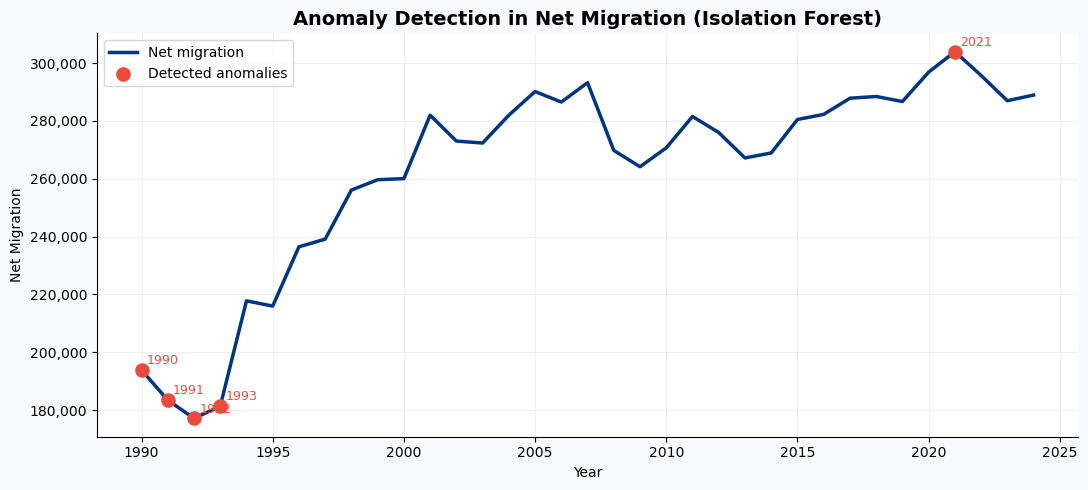

In [38]:
# ── Anomaly Detection with Isolation Forest ───────────────────────

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Use yearly net migration data
anom_df = df[["year", "net_migration"]].dropna().copy()

# Train model
iso = IsolationForest(
    contamination=0.12,   # roughly a few anomaly years
    random_state=42
)

anom_df["anomaly"] = iso.fit_predict(anom_df[["net_migration"]])

# -1 = anomaly
outliers = anom_df[anom_df["anomaly"] == -1]

print("Detected anomaly years:")
display(outliers[["year", "net_migration"]])


# ── Visualize ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11,5))

# normal trend
ax.plot(
    anom_df["year"],
    anom_df["net_migration"],
    color=FIN_BLUE,
    lw=2.5,
    label="Net migration"
)

# anomalies
ax.scatter(
    outliers["year"],
    outliers["net_migration"],
    color="#e74c3c",
    s=90,
    label="Detected anomalies",
    zorder=3
)

# labels
for _, row in outliers.iterrows():
    ax.text(
        row["year"] + 0.2,
        row["net_migration"] + 2000,
        str(int(row["year"])),
        fontsize=9,
        color="#e74c3c"
    )

ax.set_title("Anomaly Detection in Net Migration (Isolation Forest)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Migration")
ax.yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

ax.legend()
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Anomalies were identified using the Isolation Forest algorithm, which detects years whose net migration values differ significantly from the normal historical pattern.

## Step 14 — Summary of Findings

### Population Trends
- Finland’s population has grown slowly in recent years.
- Net migration has become an important driver of population growth.

### Birth Rate and Natural Increase
- Birth rates have declined over time.
- Deaths have exceeded births, creating negative natural increase.

### Forecasting (2030–2040)
- Population growth is expected to remain slow in the coming years.
- Aging is likely to continue, increasing pressure on public services.

### Municipality Clustering
- Municipalities with lower elderly shares generally showed stronger growth.
- Older municipalities were more likely to experience decline.
- Some municipalities showed mixed patterns influenced by migration.

### Anomaly Detection
- 2021 was identified as an unusually high migration year.
- 1990–1993 were unusually low migration years compared with later trends.

### Regional and Service Needs
- Helsinki, Espoo, Tampere and other urban areas are likely to need more housing, schools, daycare, and transport.
- Aging municipalities may need more healthcare, elderly care, and support services.
- Declining municipalities may need to reorganize schools, budgets, and local services.